# **Preparing Dependencies**

In [2]:
# If dependencies are missing, install with uv in terminal:
# uv add torch diffusers transformers accelerate safetensors

import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from IPython.display import display

# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [3]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
 )
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    use_karras_sigmas=True,
 )
pipe = pipe.to(DEVICE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## **Generate Image**

  0%|          | 0/50 [00:00<?, ?it/s]

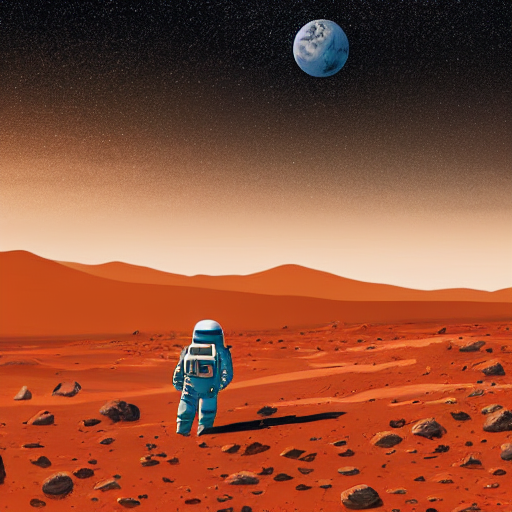

In [21]:
def generate_simple_image(
        prompt: str, 
        negative_prompt: str = "", 
        seed: int = 42,
        width: int = 512,
        height: int = 512,
        ):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        width=width,
        height=height,
    )
    return result.images[0]

TARGET_PROMPT = (
    "A lone cartoon astronaut on a barren Mars-like landscape, Earth rising in the black starry sky, orthographic perspective, simple clean line art, cute whimsical sci-fi illustration, soft warm lighting, high contrast, vivid colors, no text, no watermark."
)

TARGET_NEGATIVE_PROMPT = (
    "low quality, worst quality, blurry, gradient, bad anatomy, bad hands, extra fingers, missing fingers, extra limbs, distorted, cropped, jpeg artifacts, text, watermark, signature, username, oversaturated"
)

TARGET_SEED = 222

simple_image = generate_simple_image(
    prompt=TARGET_PROMPT,
    negative_prompt=TARGET_NEGATIVE_PROMPT,
    seed=TARGET_SEED,
)
display(simple_image)

## **Generate Image with Hyperparameter Configuration**

  0%|          | 0/50 [00:00<?, ?it/s]

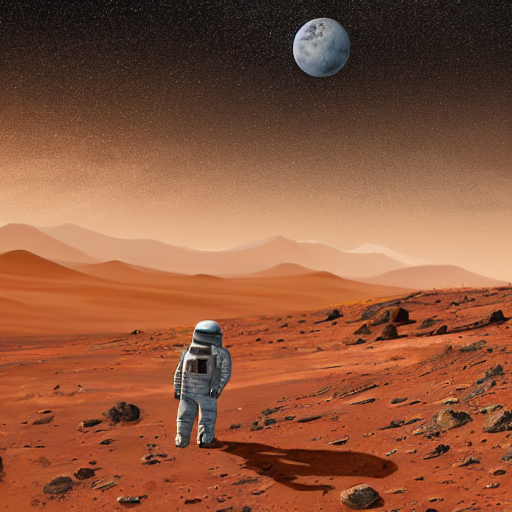

In [24]:
def generate_advanced_image(
    prompt: str,
    negative_prompt: str = "",
    seed: int = 42,
    guidance_scale: float = 7.5,
    num_inference_step: int = 50,
):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=float(guidance_scale),
        num_inference_steps=int(num_inference_step),
    )
    return result.images[0]

TARGET_NEGATIVE_PROMPT = (
    "low quality, worst quality, blurry, gradient, bad anatomy, bad hands, extra fingers, missing fingers, extra limbs, distorted, cropped, jpeg artifacts, text, watermark, signature, username, oversaturated"
)

advanced_image = generate_advanced_image(
    prompt=TARGET_PROMPT,
    negative_prompt=TARGET_NEGATIVE_PROMPT,
    seed=TARGET_SEED,
    guidance_scale=5.0,
    num_inference_step=50,
)
display(advanced_image)

## **Guidance Scale Comparison**

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
*"Gambar terlihat lebih bebas dan sedikit kurang ketat mengikuti prompt. Detail masih cukup jelas, tetapi ada variasi visual yang lebih besar, sehingga hasilnya terasa lebih natural dan sedikit lebih kreatif. Pada contoh ini, astronaut dan lanskap Mars tetap muncul, namun komposisi dan nuansa gambar terasa lebih longgar."*

*   **Gambar dengan "Scale" Tinggi:**   
*"Sangat mengikuti prompt namun menghasilkan output yang hampir tidak ada bedanya dengan generate image tanpa hyperparameter, hanya ditambahkan beberapa detail kecil yang tidak terlalu signifikan."*

## **Inference Steps Comparison**

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
*"Gambar cenderung lebih sederhana dan detailnya belum sepenuhnya matang. Ketajaman bisa lebih rendah, dan ada kemungkinan terlihat noise, tekstur kasar, atau bentuk yang belum terlalu stabil. Hasilnya biasanya masih cukup menggambarkan prompt, tetapi elemen visualnya belum sepenuhnya halus."*
*   **Gambar dengan "Step" Tinggi:**  
*"Gambar terlihat lebih detail, lebih halus, dan lebih stabil secara visual. Objek utama menjadi lebih tegas, komposisi lebih rapi, dan noise atau artefak cenderung berkurang. Dibandingkan step rendah, hasilnya biasanya memberi kesan lebih selesai dan lebih nyaman dilihat."*

## **Batch Inference from One Prompt**

## **Load Scheduler**

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

## **Inpainting**

### **Load Model Inpainting**

In [25]:
from diffusers import StableDiffusionInpaintPipeline

INPAINT_MODEL_ID = "runwayml/stable-diffusion-inpainting"

inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    INPAINT_MODEL_ID,
    torch_dtype=DTYPE,
)
inpaint_pipe = inpaint_pipe.to(DEVICE)


def inpaint_engine(image, mask, prompt, negative_prompt="", seed=42):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = inpaint_pipe(
        prompt=prompt,
        image=image,
        mask_image=mask,
        negative_prompt=negative_prompt,
        generator=generator,
    )
    return result.images[0]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise 

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


### **Manual Masking**

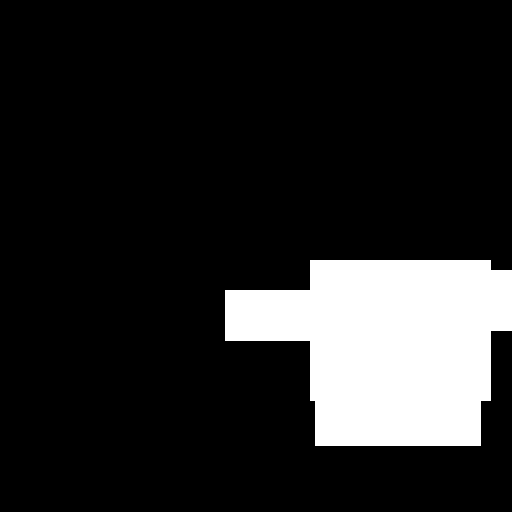

In [26]:
from PIL import Image, ImageDraw

# simple_image is 512x512; white = repaint, black = keep.
# Place the satellite clearly to the right of the astronaut on the Mars surface.
w, h = simple_image.size  # 512x512

mask = Image.new("RGB", (w, h), "black")
draw = ImageDraw.Draw(mask)

# Large satellite body on the ground
draw.rectangle([310, 260, 490, 400], fill="white")
# Left solar panel stretching toward the astronaut
draw.rectangle([225, 290, 315, 340], fill="white")
# Right solar panel stretching outward (partially off-canvas is fine)
draw.rectangle([488, 270, 512, 330], fill="white")
# Debris pile below the body
draw.rectangle([315, 395, 480, 445], fill="white")

display(mask)

### **Generate**

  0%|          | 0/50 [00:00<?, ?it/s]

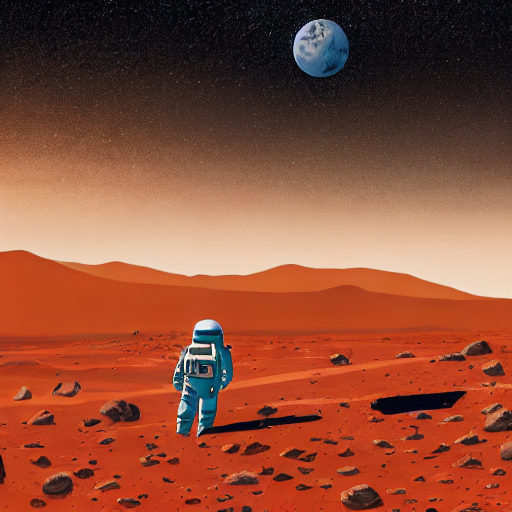

In [27]:
INPAINT_PROMPT = (
    "a wrecked satellite sitting on red Martian soil next to an astronaut, "
    "large golden solar panels bent outward to both sides, central metallic body, "
    "crash debris and broken parts on the ground, "
    "2D digital illustration, clean flat color art style"
)
INPAINT_NEGATIVE_PROMPT = (
    "photorealistic, realistic, photograph, 3D render, messy, blurry, "
    "low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"
)

inpainted_image = inpaint_engine(
    image=simple_image,
    mask=mask,
    prompt=INPAINT_PROMPT,
    negative_prompt=INPAINT_NEGATIVE_PROMPT,
    seed=9,
)
display(inpainted_image)

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

### **Masking with Segmentation Model**

### **Generate**

## **Outpainting**

### **Prepare the Canvas**

### **Generate**

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

### **Generate**